# **Seaborn Intro**

In [81]:
# Import Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [82]:
df_DA_DE = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

df_DA_DE = df_DA_DE.dropna(subset=['salary_year_avg'])

# **BarH**

In [83]:
df_DA_DE = df_DA_DE.explode('job_skills')

df_DA_DE[['job_skills','salary_year_avg']]

df_DA_DE_grouped = df_DA_DE.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DA_top_pay = df_DA_DE_grouped.sort_values(by='median', ascending=False).head(10)

df_DA_skills = df_DA_DE_grouped.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

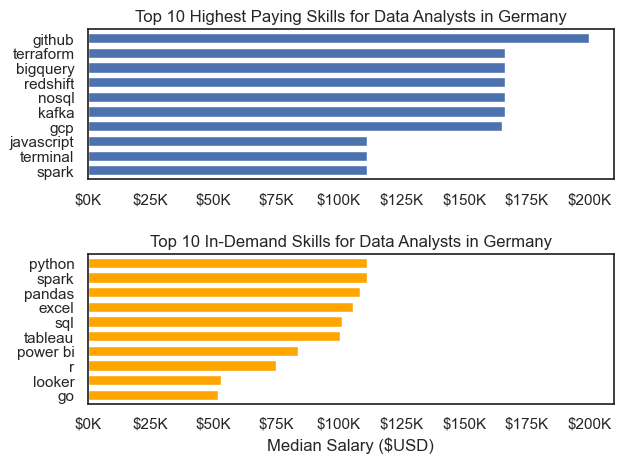

In [84]:
fig, ax = plt.subplots(2, 1)

df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False, width=0.7)
df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False, width=0.7, color='orange')

ax[0].set_title('Top 10 Highest Paying Skills for Data Analysts in Germany')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_title('Top 10 In-Demand Skills for Data Analysts in Germany')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
fig.tight_layout()

fig.subplots_adjust(hspace=0.5)
plt.show()

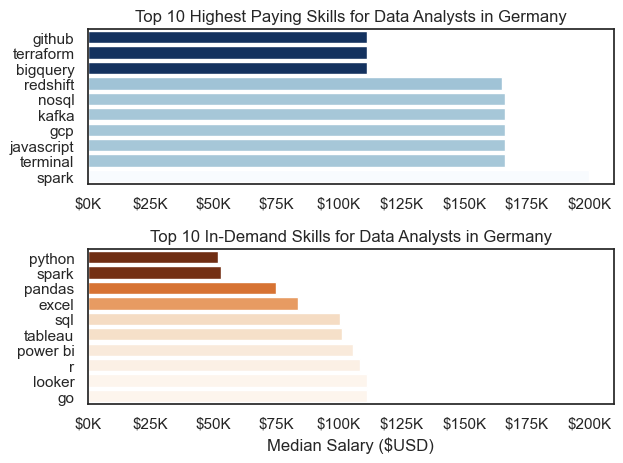

In [85]:
fig, ax = plt.subplots(2, 1)

sns.barplot(data=df_DA_top_pay[::-1], x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='Blues_r')
#df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False, width=0.7)
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paying Skills for Data Analysts in Germany')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_skills[::-1], x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='Oranges_r')
#df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False, width=0.7, color='orange')
ax[1].legend().remove()
ax[1].set_title('Top 10 In-Demand Skills for Data Analysts in Germany')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())

fig.tight_layout()
plt.show()


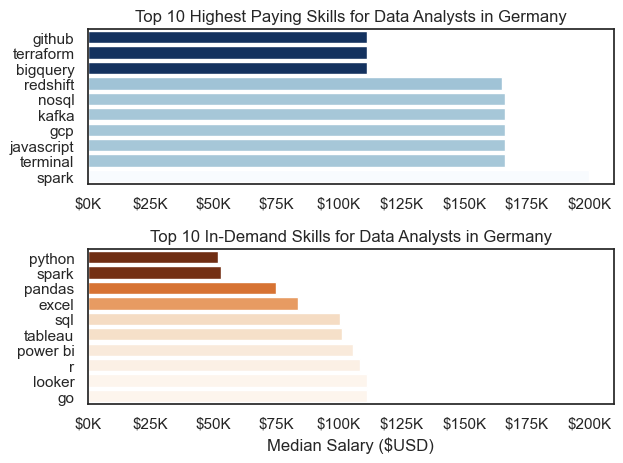

In [86]:
fig, ax = plt.subplots(2, 1)

sns.set_style("white")

sns.barplot(data=df_DA_top_pay[::-1], x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='Blues_r')
#df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False, width=0.7)
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paying Skills for Data Analysts in Germany')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_skills[::-1], x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='Oranges_r')
#df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False, width=0.7, color='orange')
ax[1].legend().remove()
ax[1].set_title('Top 10 In-Demand Skills for Data Analysts in Germany')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())

fig.tight_layout()
plt.show()


# **Histogram**

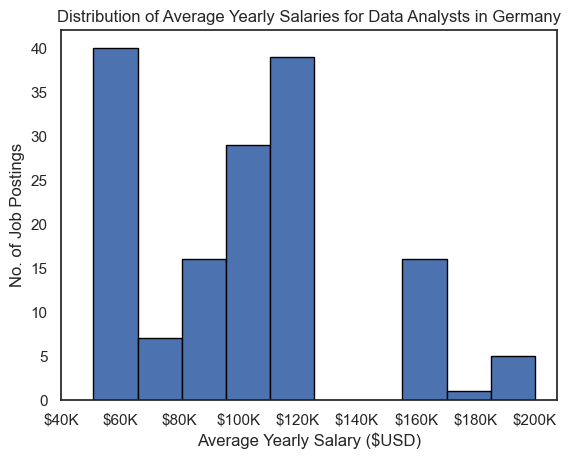

In [87]:
df_DA_DE['salary_year_avg'].plot(kind='hist', bins=10, edgecolor='black')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.title('Distribution of Average Yearly Salaries for Data Analysts in Germany')
plt.xlabel('Average Yearly Salary ($USD)')
plt.xlim(40000)
plt.ylabel('No. of Job Postings')
plt.show()

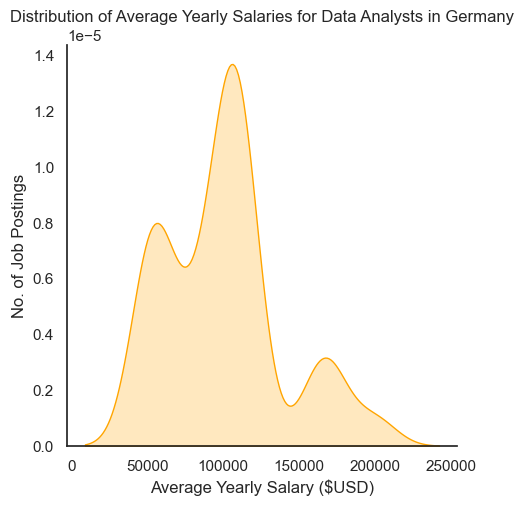

In [88]:
sns.set_style('white')
sns.displot(df_DA_DE['salary_year_avg'], kind='kde', fill=True, color='orange', height=5)

plt.title('Distribution of Average Yearly Salaries for Data Analysts in Germany')
plt.xlabel('Average Yearly Salary ($USD)')
plt.xlim()
plt.ylabel('No. of Job Postings')
plt.show()

# **Boxplot**

In [91]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_DE = df[(df['job_title_short'].isin(job_titles) & (df['job_country'] == 'Germany'))].copy()
df_DE = df_DE.dropna(subset=['salary_year_avg'])

job_list = [df_DE[df_DE['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

/var/folders/x4/q8t78mvx6xs5b2jwtybtn5rw0000gn/T/ipykernel_90947/1739449348.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, vert=False, labels=job_titles)


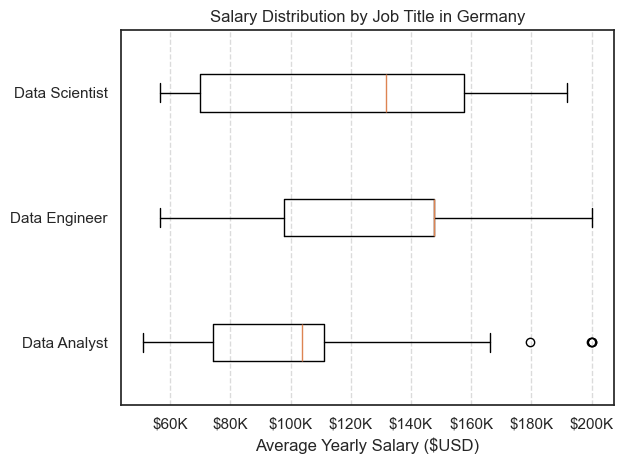

In [92]:
plt.boxplot(job_list, vert=False, labels=job_titles)
plt.title('Salary Distribution by Job Title in Germany')
plt.xlabel('Average Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

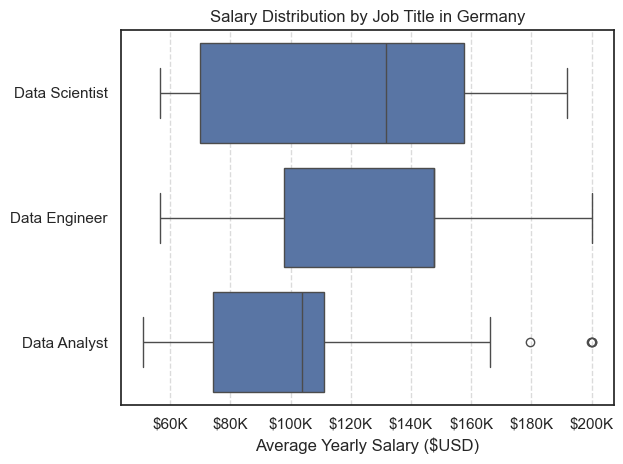

In [97]:
sns.set_style('white')

sns.boxplot(data=df_DE, x='salary_year_avg', y='job_title_short')
#plt.boxplot(job_list, vert=False, labels=job_titles)
plt.title('Salary Distribution by Job Title in Germany')
plt.xlabel('Average Yearly Salary ($USD)')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()